In [1]:
import numpy as np
import matplotlib.pyplot as plt
import eigsep_style as es
from hera_filters.dspec import gen_window


In [2]:
def delay_plot(dly, dspec, title=None, save=False, save_path="reflections.pdf"):
    es.apply_rc()
    plt.figure(figsize=es.figsize(cols=1, height_in=2.3934), layout="constrained")
    for h, d in dspec.items():
        plt.plot(np.fft.fftshift(dly), np.fft.fftshift(np.abs(d)), label=f"{float(h):3.0f} m")
    plt.xlabel("Delay [ns]", fontsize=8)
    plt.ylabel("Environmental Delay Spectrum [arb.]", fontsize=8)
    plt.grid()
    plt.xlim(0, 1000)
    plt.ylim(1e-11, 1) 
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.yscale("log")
    plt.legend(ncols=2, loc="upper right", fontsize=7)
    if title:
        plt.title(title)
    if save:
        es.save(plt.gcf(), save_path)

In [3]:
terrain_npz = np.load("s11_terrain.npz", allow_pickle=True)
spec = terrain_npz["spec"]          # (n_height, NCHAN) complex; pre-window frequency spectrum
heights = terrain_npz["heights"]    # snapped grid heights, same row order as spec
freqs = terrain_npz["freqs"]
params = terrain_npz["params"].item()

window = gen_window(params["window"], freqs.size)
s11_delay = np.fft.ifft(spec * window, axis=-1)
power = np.abs(s11_delay) ** 2
norm = power[np.argmin(np.abs(heights - 1.0))].sum()  # normalize to the 1 m curve
dspec_ratio = power / norm

dly = np.fft.fftfreq(freqs.size, d=freqs[1] - freqs[0]) * 1e9
dspec = {str(h): dspec_ratio[i] for i, h in enumerate(heights)}


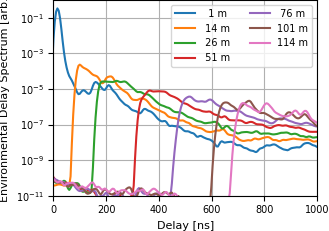

In [4]:
delay_plot(dly, dspec, save=True)